# 고객 소비 패턴 분석

`cc_num`, `category`, `amt`를 기준으로 고객별 소비 성향을 분석합니다.

확인할 내용:

- 고객별/카테고리별 거래횟수
- 고객별/카테고리별 총소비금액
- 고객별/카테고리별 평균소비금액
- 상위 소비 고객 10명의 주요 소비 카테고리
- 카테고리별 전체 소비 금액

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display
from matplotlib import font_manager

In [2]:
# 한글 폰트 설정
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

display(HTML("""
<style>
.jp-Notebook { font-size: 13px; }
.jp-RenderedMarkdown { font-size: 13px; line-height: 1.55; }
.jp-RenderedMarkdown h1 { font-size: 22px; }
.jp-RenderedMarkdown h2 { font-size: 17px; }
.jp-RenderedMarkdown h3 { font-size: 15px; }
.jp-OutputArea-output, .jp-RenderedText, .jp-OutputArea pre { font-size: 12px; }
.dataframe { font-size: 11px; }
</style>
"""))

## 1. 데이터 로드

현재 프로젝트에는 `data/credit_card_transactions.csv`가 없을 수 있으므로, 없으면 `step1/data/credit_card_transactions.csv`를 자동으로 사용합니다.

In [3]:
def get_data_path():
    current_dir = Path.cwd()
    candidates = [
        current_dir / "data" / "credit_card_transactions.csv",
        current_dir / "step1" / "data" / "credit_card_transactions.csv",
        current_dir.parent / "data" / "credit_card_transactions.csv",
        current_dir.parent / "step1" / "data" / "credit_card_transactions.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "credit_card_transactions.csv 파일을 찾을 수 없습니다. "
        "data/ 또는 step1/data/ 폴더를 확인하세요."
    )


data_path = get_data_path()
print(f"[데이터 파일] {data_path}")

df = pd.read_csv(data_path)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

required_columns = {"cc_num", "category", "amt"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"필수 컬럼이 없습니다: {sorted(missing_columns)}")

print(df.shape)
df.head()

[데이터 파일] /Users/sungjh/Projects/hana_power_on/step1/data/credit_card_transactions.csv
(1296675, 23)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


## 2. 고객별/카테고리별 소비 패턴 집계

고객 번호(`cc_num`)와 소비 카테고리(`category`)를 함께 묶어서, 고객이 어떤 영역에 자주 쓰고 많이 쓰는지 확인합니다.

In [4]:
customer_category = (
    df.groupby(["cc_num", "category"])
    .agg(
        거래횟수=("amt", "count"),
        총소비금액=("amt", "sum"),
        평균소비금액=("amt", "mean"),
    )
    .reset_index()
)

customer_category.sort_values("총소비금액", ascending=False).head(20)

,cc_num,category,거래횟수,총소비금액,평균소비금액
3365,180048185037117,grocery_pos,332,66730.11,200.994307
2968,36722699017270,grocery_pos,332,66329.44,199.787470
4342,344709867813900,grocery_pos,326,65881.72,202.091166
11307,6011893664860915,grocery_pos,317,64061.69,202.087350
5983,2712209726293386,grocery_pos,317,63460.80,200.191798
8200,3590736522064285,grocery_pos,313,62498.61,199.676070
10169,4836998673805450,grocery_pos,310,62225.82,200.728452
11070,6011438889172900,grocery_pos,303,61387.65,202.599505
3745,213141712584544,grocery_pos,306,61291.77,200.299902
10328,4908846471916297,grocery_pos,301,60814.03,202.039967


## 3. 고객별 대표 소비 카테고리

- `최다거래카테고리`: 가장 자주 결제한 카테고리
- `최대소비카테고리`: 가장 많은 금액을 쓴 카테고리

In [5]:
top_category_by_count = (
    customer_category.sort_values(
        ["cc_num", "거래횟수", "총소비금액"],
        ascending=[True, False, False],
    )
    .drop_duplicates("cc_num")
    .set_index("cc_num")
)

top_category_by_amount = (
    customer_category.sort_values(
        ["cc_num", "총소비금액", "거래횟수"],
        ascending=[True, False, False],
    )
    .drop_duplicates("cc_num")
    .set_index("cc_num")
)

customer_summary = df.groupby("cc_num").agg(
    총소비금액=("amt", "sum"),
    평균소비금액=("amt", "mean"),
    거래횟수=("amt", "count"),
)

top_spenders = customer_summary.sort_values("총소비금액", ascending=False).head(10)
top_spender_patterns = top_spenders.copy()
top_spender_patterns["최다거래카테고리"] = top_category_by_count.loc[
    top_spender_patterns.index, "category"
]
top_spender_patterns["최다거래카테고리횟수"] = top_category_by_count.loc[
    top_spender_patterns.index, "거래횟수"
]
top_spender_patterns["최대소비카테고리"] = top_category_by_amount.loc[
    top_spender_patterns.index, "category"
]
top_spender_patterns["최대소비카테고리금액"] = top_category_by_amount.loc[
    top_spender_patterns.index, "총소비금액"
]

top_spender_patterns

,총소비금액,평균소비금액,거래횟수,최다거래카테고리,최다거래카테고리횟수,최대소비카테고리,최대소비카테고리금액
cc_num,,,,,,,
6011367958204270,296436.73,95.317277,3110,shopping_pos,368,grocery_pos,59064.45
4908846471916297,290478.49,95.583577,3039,shopping_pos,339,grocery_pos,60814.03
6011438889172900,284013.50,91.440277,3106,shopping_pos,359,grocery_pos,61387.65
36722699017270,280008.05,89.774944,3119,shopping_pos,337,grocery_pos,66329.44
6011893664860915,278325.97,90.073129,3090,shopping_pos,358,grocery_pos,64061.69
6011109736646996,278139.27,89.693412,3101,shopping_pos,333,grocery_pos,57465.17
3583635130604947,278042.99,91.884663,3026,shopping_pos,379,grocery_pos,56532.11
2712209726293386,277085.65,90.432653,3064,shopping_pos,340,grocery_pos,63460.80
4836998673805450,275930.63,91.156468,3027,shopping_pos,333,grocery_pos,62225.82


## 4. 카테고리별 전체 소비 금액

전체 고객 기준으로 어떤 카테고리에 가장 많은 돈이 쓰였는지 확인합니다.

In [6]:
category_spend = df.groupby("category")["amt"].sum().sort_values(ascending=False)
category_spend

category
grocery_pos       14460822.38
shopping_pos       9307993.61
shopping_net       8625149.68
gas_transport      8351732.29
home               7173928.11
kids_pets          6503680.16
entertainment      6036678.56
misc_net           5117709.26
misc_pos           5009582.50
food_dining        4672459.44
health_fitness     4653108.02
travel             4516721.68
personal_care      4353450.53
grocery_net        2439412.68
Name: amt, dtype: float64

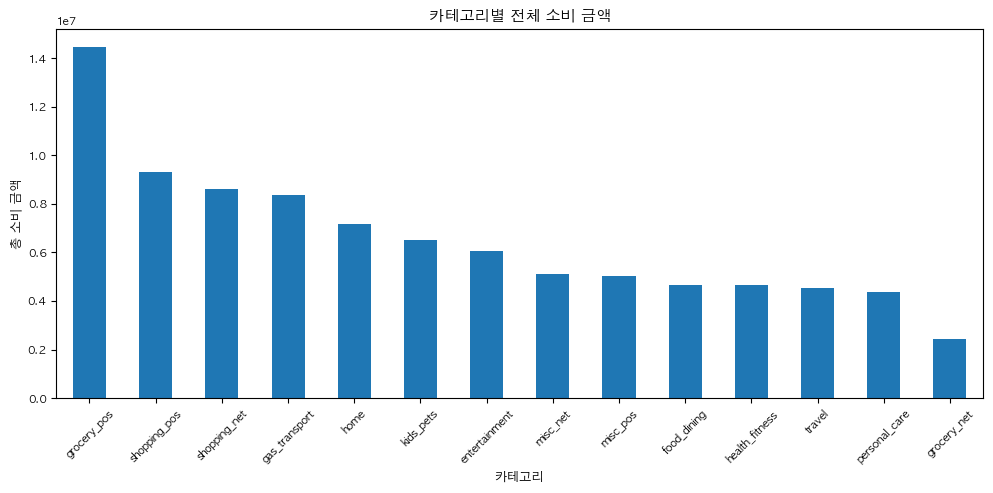

In [7]:
plt.figure(figsize=(10, 5))
category_spend.plot(kind="bar")
plt.title("카테고리별 전체 소비 금액")
plt.xlabel("카테고리")
plt.ylabel("총 소비 금액")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. 결과 해석

- 거래횟수가 가장 많은 카테고리: 고객이 자주 이용하는 소비 영역
- 총소비금액이 가장 큰 카테고리: 고객이 가장 많은 돈을 쓰는 영역
- 평균소비금액이 큰 카테고리: 한 번 결제할 때 금액이 큰 소비 영역

예시 해석:

- `grocery_pos` 비중이 높으면 식료품/생활 소비 중심 고객으로 볼 수 있습니다.
- `travel` 또는 `shopping_net` 금액이 크면 여행/온라인 쇼핑 중심 고객으로 볼 수 있습니다.
- 특정 카테고리에 거래가 몰려 있으면 마케팅 타겟 분류에 활용할 수 있습니다.